✅ Using dataset: ../data/processed/soil_reduced_features.csv
✅ Data loaded successfully!
         State    District Farmer_ID Soil_Type   pH    EC    OC    N   P    K  \
0  West Bengal  Darjeeling     F1000     Silty  5.9  0.75  0.53  236  37  149   
1  Maharashtra      Nagpur     F1001     Sandy  8.7  0.67  1.16  160  24  171   
2       Punjab    Ludhiana     F1002     Silty  7.1  1.06  0.88  173  15  114   
3        Bihar       Patna     F1003     Sandy  4.7  0.16  1.30  319  21  100   
4       Punjab    Amritsar     F1004     Loamy  4.8  0.99  0.81  395  18   93   

   Moisture Crop_Suitability  
0        34            Wheat  
1        37             Rice  
2        35            Wheat  
3        37           Pulses  
4        38             Rice  
✅ Best model loaded successfully!
🔢 Encoding categorical columns: ['State', 'District', 'Farmer_ID', 'Soil_Type', 'Crop_Suitability']
✅ Train-test split completed!
✅ Model Accuracy: 0.90

📋 Classification Report:
              precision  

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

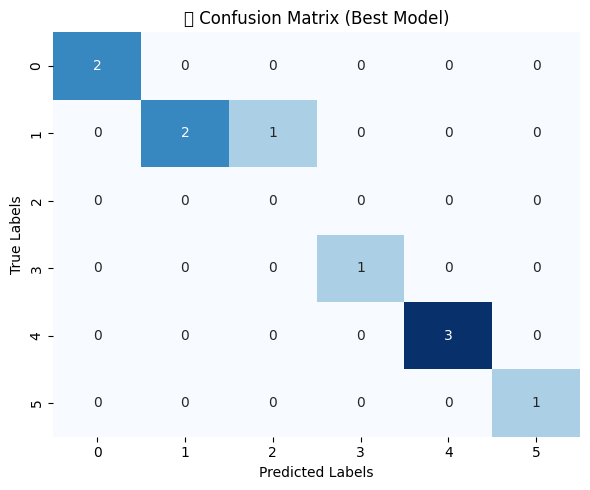

✅ Model evaluation report saved to: ../reports/model_evaluation_report.txt


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

In [3]:
# ------------------------------------------------------------
# 🌱 Soil Health Prediction - Model Evaluation (Member 1)
# ------------------------------------------------------------

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ------------------------------------------------------------
# 2️⃣ Load Data & Model
# ------------------------------------------------------------
data_path = '../data/processed/soil_reduced_features.csv'

if not os.path.exists(data_path):
    print("⚠️ 'soil_reduced_features.csv' not found. Checking alternatives...")
    alternatives = [
        '../data/processed/cleaned_soil_data.csv',
        '../data/processed/soil_feature_importances.csv'
    ]
    for alt in alternatives:
        if os.path.exists(alt):
            data_path = alt
            print(f"✅ Found alternative file: {alt}")
            break
else:
    print(f"✅ Using dataset: {data_path}")

df = pd.read_csv(data_path)
print("✅ Data loaded successfully!")
print(df.head())

# ------------------------------------------------------------
# 3️⃣ Load Optimized Model
# ------------------------------------------------------------
model_path = '../data/processed/best_model.pkl'
if not os.path.exists(model_path):
    raise FileNotFoundError("❌ Model file not found. Make sure 'best_model.pkl' exists in ../data/processed/")

best_model = joblib.load(model_path)
print("✅ Best model loaded successfully!")

# ------------------------------------------------------------
# 4️⃣ Encode Categorical Columns (Safe Label Encoding)
# ------------------------------------------------------------
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

if len(cat_cols) > 0:
    print(f"🔢 Encoding categorical columns: {cat_cols}")
    encoder = LabelEncoder()
    for col in cat_cols:
        df[col] = encoder.fit_transform(df[col].astype(str))
else:
    print("✅ No categorical columns found for encoding.")

# ------------------------------------------------------------
# 5️⃣ Split Data
# ------------------------------------------------------------
if 'Crop_Suitability' not in df.columns:
    raise KeyError("❌ Target column 'Crop_Suitability' not found in the dataset!")

X = df.drop('Crop_Suitability', axis=1)
y = df['Crop_Suitability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("✅ Train-test split completed!")

# ------------------------------------------------------------
# 6️⃣ Model Evaluation
# ------------------------------------------------------------
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Model Accuracy: {accuracy:.2f}")

print("\n📋 Classification Report:")
print(classification_report(y_test, y_pred))

# ------------------------------------------------------------
# 7️⃣ Confusion Matrix Visualization
# ------------------------------------------------------------
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("🌾 Confusion Matrix (Best Model)")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.tight_layout()

os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/confusion_matrix_best_model.png")
plt.show()

# ------------------------------------------------------------
# 8️⃣ Save Evaluation Report
# ------------------------------------------------------------
os.makedirs("../reports", exist_ok=True)
report_path = "../reports/model_evaluation_report.txt"

with open(report_path, "w") as f:
    f.write("🌾 Soil Health Prediction Model Evaluation Report\n")
    f.write("================================================\n\n")
    f.write(f"Model Accuracy: {accuracy:.2f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_test, y_pred))
    f.write("\nConfusion Matrix:\n")
    f.write(np.array2string(cm))

print(f"✅ Model evaluation report saved to: {report_path}")
